# L04/L06：Patch坐标与HybridSN张量流

模型使用随机权重，仅验证接口和结构；不将其输出当作训练成绩。

In [1]:
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/hsi_learning').is_dir() and (p / 'dataset').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from inside the HSI-Learning repository')
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np
import torch
# Notebook kernels must explicitly use inline rendering even when the CLI
# parent uses MPLBACKEND=Agg for non-interactive training scripts.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
import matplotlib.pyplot as plt
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_runs import load_bundle, encode_ids
from hsi_learning.teaching import patches_at, prototype_logits, prototypes, grad_cam
from hsi_learning.teaching_plots import style, maps
style()
torch.set_num_threads(2)
print('Python:', sys.executable)
print('Repository:', ROOT)


Python: D:\JupyterWorkSpace\HSI-Learning\.venv\Scripts\python.exe
Repository: D:\JupyterWorkSpace\HSI-Learning


Center 12 patch: tensor([[ 6.,  7.,  8.],
        [11., 12., 13.],
        [16., 17., 18.]])


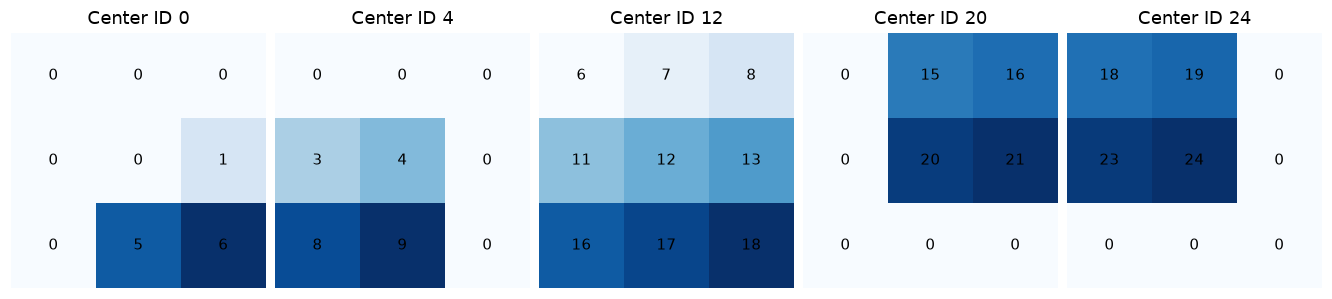

Even patch rejected as expected


In [2]:
toy=np.arange(25,dtype=np.float32).reshape(5,5,1)
ids=np.array([0,4,12,20,24]); patches=patches_at(toy,ids,3)
np.testing.assert_array_equal(patches[:,0,1,1].numpy(),toy.ravel()[ids])
print('Center 12 patch:',patches[2,0])
fig,axes=plt.subplots(1,5,figsize=(12,3),layout='constrained')
for ax,p,i in zip(axes,patches,ids):
    ax.imshow(p[0],cmap='Blues'); ax.set_title(f'Center ID {i}')
    for r in range(3):
        for c in range(3): ax.text(c,r,int(p[0,r,c]),ha='center',va='center')
    ax.axis('off')
plt.show()
try: patches_at(toy,ids,4)
except ValueError: print('Even patch rejected as expected')
else: raise AssertionError('Even patch must be rejected')


In [3]:
from hsi_learning.models import HybridSN
net=HybridSN(15,25,16).eval(); batch=torch.zeros(2,15,25,25)
shapes={}; handles=[]
for name in ['conv1','conv2','conv3','conv4','dense1','dense2','dense3']:
    def record(module,args,output,name=name): shapes[name]=tuple(output.shape)
    handles.append(getattr(net,name).register_forward_hook(record))
try:
    with torch.no_grad(): logits=net(batch)
finally:
    for handle in handles: handle.remove()
print(shapes)
assert shapes['conv3']==(2,32,3,19,19)
assert shapes['conv4']==(2,64,17,17)
assert logits.shape==(2,16)


{'conv1': (2, 8, 9, 23, 23), 'conv2': (2, 16, 5, 21, 21), 'conv3': (2, 32, 3, 19, 19), 'conv4': (2, 64, 17, 17), 'dense1': (2, 256), 'dense2': (2, 128), 'dense3': (2, 16)}


In [4]:
tensor=torch.arange(2*32*3*19*19).reshape(2,32,3,19,19)
merged=tensor.reshape(2,96,19,19)
assert tensor.numel()==merged.numel()
assert merged[1,2*3+1,5,7]==tensor[1,2,1,5,7]
print('C,D merge:',tensor.shape,'->',merged.shape)
print('First FC params:',sum(p.numel() for p in net.dense1.parameters()))


C,D merge: torch.Size([2, 32, 3, 19, 19]) -> torch.Size([2, 96, 19, 19])
First FC params: 4735232


In [5]:
other=HybridSN(30,25,16).eval()
assert other.conv4[0].in_channels==32*18
with torch.no_grad(): assert other(torch.zeros(2,30,25,25)).shape==(2,16)
print('PCA30 depth: 30->24->20->18; Conv2d input:',other.conv4[0].in_channels)


PCA30 depth: 30->24->20->18; Conv2d input: 576


## 退出题
reshape是否减少元素数？
为什么PCA15变30会影响Conv2d通道数？
如何检查shuffle之后预测回贴位置？

实测模型结果另见协议E的Notebook15；历史HybridSN训练见Notebook03。